# 07. Final Model Evaluation & Selection



In [1]:
import json
import pickle
import sqlite3
import sys
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from oracle.evaluation.metrics import calculate_classification_metrics, mcnemar_test
from oracle.evaluation.report import export_evaluation_summary
from oracle.evaluation.visualizations import (
    plot_calibration_curve,
    plot_confusion_matrix,
    plot_feature_importance,
    plot_pr_curve,
    plot_roc_curve,
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports" / "evaluation"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "evaluation"
MLFLOW_DB_PATH = PROJECT_ROOT / "mlflow.db"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

DISPLAY_NAMES = {
    "lightgbm": "LightGBM",
    "random_forest": "Random Forest",
    "svm_linear": "Linear SVM",
    "svm_rbf": "RBF SVM",
    "xgboost": "XGBoost",
}
METRIC_KEYS = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc",
    "brier_score",
    "log_loss",
]


def _display_name(model_name: str | None) -> str:
    if not model_name:
        return "Unknown"
    return DISPLAY_NAMES.get(model_name, model_name.replace("_", " ").title())


def _feature_path(scope: str, filename: str) -> Path:
    prefix = "" if scope == "postgame" else "pregame_"
    return PROCESSED_DIR / f"{prefix}{filename}"


def _find_family_model_dir(
    family: str, *, experiment_name: str = "02-advanced-models"
 ) -> Path | None:
    family_dir = MODELS_DIR / experiment_name / family
    if not family_dir.exists():
        return None

    candidates: list[dict[str, object]] = []
    for meta_path in family_dir.glob("*/model_metadata.json"):
        metadata = json.loads(meta_path.read_text(encoding="utf-8"))
        metrics_path = meta_path.parent / "metrics.json"
        metrics = {}
        if metrics_path.exists():
            metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
        candidates.append(
            {
                "model_dir": meta_path.parent,
                "run_name": metadata.get("run_name", ""),
                "test_roc_auc": float(metrics.get("test_roc_auc", float("-inf"))),
                "updated_at": meta_path.stat().st_mtime,
            }
        )

    if not candidates:
        return None

    candidates.sort(
        key=lambda item: (
            item["run_name"] == "optuna-best-model",
            item["test_roc_auc"],
            item["updated_at"],
        ),
        reverse=True,
    )
    return Path(candidates[0]["model_dir"])


def _load_model_inputs(
    *,
    model_dir: Path,
    preprocessor_path: Path,
    test_features_path: Path,
) -> tuple[dict[str, object], object, pd.DataFrame]:
    metadata = json.loads((model_dir / "model_metadata.json").read_text(encoding="utf-8"))
    with preprocessor_path.open("rb") as handle:
        preprocessor = pickle.load(handle)
    test_df = pd.read_csv(test_features_path)
    return metadata, preprocessor, test_df


def _prepare_test_matrix(
    metadata: dict[str, object],
    preprocessor: object,
    test_df: pd.DataFrame,
) -> tuple[pd.Series, pd.DataFrame]:
    feature_columns = list(metadata["feature_columns"])
    target_col = str(metadata.get("target_column", "win"))
    y_true = test_df[target_col].astype(int)

    if set(feature_columns).issubset(test_df.columns):
        aligned = test_df.copy()
        for column in feature_columns:
            if column not in aligned.columns:
                aligned[column] = 0.0
        return y_true, aligned[feature_columns]

    preprocessor_cols: list[str] = []
    for name, _transformer, columns in preprocessor.transformers_:
        if name != "remainder":
            preprocessor_cols.extend(columns)

    aligned = test_df.copy()
    for column in preprocessor_cols:
        if column not in aligned.columns:
            aligned[column] = 0.0

    x_scaled = preprocessor.transform(aligned[preprocessor_cols])
    output_column_names = [
        name.split("__", 1)[-1] for name in preprocessor.get_feature_names_out()
    ]
    x_df = pd.DataFrame(x_scaled, columns=output_column_names, index=aligned.index)
    for column in feature_columns:
        if column not in x_df.columns:
            x_df[column] = 0.0

    return y_true, x_df[feature_columns]


def _predict_positive_scores(model: object, x_test: pd.DataFrame) -> np.ndarray | None:
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(x_test)
        if np.ndim(proba) == 2:
            return np.asarray(proba)[:, 1]
        return np.asarray(proba, dtype=float)

    if hasattr(model, "decision_function"):
        decision = np.asarray(model.decision_function(x_test), dtype=float)
        return 1.0 / (1.0 + np.exp(-decision))

    return None


def _evaluate_saved_model(model_dir: Path, *, scope: str = "postgame") -> dict[str, object]:
    metadata, preprocessor, test_df = _load_model_inputs(
        model_dir=model_dir,
        preprocessor_path=_feature_path(scope, "feature_preprocessor.pkl"),
        test_features_path=_feature_path(scope, "test_features.csv.gz"),
    )
    y_true, x_test = _prepare_test_matrix(metadata, preprocessor, test_df)

    with (model_dir / "model.pkl").open("rb") as handle:
        model = pickle.load(handle)

    y_pred = model.predict(x_test)
    y_prob = _predict_positive_scores(model, x_test)
    metrics = calculate_classification_metrics(y_true, y_pred, y_prob)
    model_name = str(metadata.get("model_name") or model_dir.parent.name)

    return {
        "display_name": _display_name(model_name),
        "model_name": model_name,
        "model_dir": model_dir,
        "run_name": metadata.get("run_name", model_dir.name),
        "feature_count": len(metadata["feature_columns"]),
        "y_true": y_true,
        "x_test": x_test,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "model": model,
        "metrics": metrics,
    }


def _load_mlflow_runs(experiment_id: int) -> pd.DataFrame:
    if not MLFLOW_DB_PATH.exists():
        return pd.DataFrame()

    query = """
    select
      r.name as run_name,
      p.value as model_name,
      r.artifact_uri,
      max(case when m.key='test_accuracy' then m.value end) as accuracy,
      max(case when m.key='test_precision' then m.value end) as precision,
      max(case when m.key='test_recall' then m.value end) as recall,
      max(case when m.key='test_f1' then m.value end) as f1,
      max(case when m.key='test_roc_auc' then m.value end) as roc_auc,
      max(case when m.key='test_pr_auc' then m.value end) as pr_auc,
      max(case when m.key='test_brier_score' then m.value end) as brier_score,
      max(case when m.key='test_log_loss' then m.value end) as log_loss,
      max(case when m.key='val_accuracy' then m.value end) as val_accuracy,
      max(case when m.key='val_roc_auc' then m.value end) as val_roc_auc
    from runs r
    left join params p on r.run_uuid = p.run_uuid and p.key = 'model_name'
    left join latest_metrics m on r.run_uuid = m.run_uuid
    where r.experiment_id = ?
    group by r.run_uuid, r.name, p.value, r.artifact_uri
    order by roc_auc desc, accuracy desc, f1 desc
    """

    with sqlite3.connect(MLFLOW_DB_PATH) as connection:
        frame = pd.read_sql_query(query, connection, params=(experiment_id,))

    if frame.empty:
        return frame

    frame["display_name"] = frame["model_name"].map(_display_name)
    return frame


print(f"Project root: {PROJECT_ROOT}")
print(f"Processed dir: {PROCESSED_DIR}")
print(f"Models dir: {MODELS_DIR}")
print(f"MLflow DB: {MLFLOW_DB_PATH}")

Project root: /home/amir/dev/lol-match-oracle
Processed dir: /home/amir/dev/lol-match-oracle/data/processed
Models dir: /home/amir/dev/lol-match-oracle/models
MLflow DB: /home/amir/dev/lol-match-oracle/mlflow.db


/home/amir/dev/lol-match-oracle/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Held-Out Test Set

In [2]:
artifact_inputs_available = (
    _feature_path("postgame", "test_features.csv.gz").exists()
    and _feature_path("postgame", "feature_preprocessor.pkl").exists()
)

if artifact_inputs_available:
    test_df = pd.read_csv(_feature_path("postgame", "test_features.csv.gz"))
    y_test = test_df["win"].astype(int)
    print(f"Resolved test features: {_feature_path('postgame', 'test_features.csv.gz')}")
    print(f"Test set shape: {test_df.shape}")
    display(test_df[["matchid", "teamid", "win"]].head())
else:
    test_df = None
    y_test = None
    print("Processed post-game test artifacts are not available in this workspace.")
    print("The notebook will fall back to MLflow-tracked test metrics when saved model files are missing.")

Resolved test features: /home/amir/dev/lol-match-oracle/data/processed/test_features.csv.gz
Test set shape: (71708, 38)


,matchid,teamid,win
0,10,100,0
1,10,200,1
2,21,100,0
3,21,200,1
4,22,100,1


## 2. Load Tuned Models

In [3]:
candidate_families = ["xgboost", "lightgbm", "random_forest", "svm_rbf", "svm_linear"]
model_bundles: dict[str, dict[str, object]] = {}
preds: dict[str, np.ndarray] = {}
probs: dict[str, np.ndarray] = {}
comparison_rows: list[dict[str, object]] = []
evaluation_mode = "mlflow"

if artifact_inputs_available and MODELS_DIR.exists():
    for family in candidate_families:
        model_dir = _find_family_model_dir(family)
        if model_dir is None:
            continue
        try:
            bundle = _evaluate_saved_model(model_dir)
        except FileNotFoundError as error:
            print(f"Skipping {family}: {error}")
            continue
        except ValueError as error:
            print(f"Skipping {family}: {error}")
            continue

        model_bundles[bundle["display_name"]] = bundle
        preds[bundle["display_name"]] = bundle["y_pred"]
        if bundle["y_prob"] is not None:
            probs[bundle["display_name"]] = bundle["y_prob"]
        comparison_rows.append(
            {
                "model": bundle["display_name"],
                "model_name": bundle["model_name"],
                "run_name": bundle["run_name"],
                **bundle["metrics"],
            }
        )

if comparison_rows:
    evaluation_mode = "artifacts"
    comparison_df = pd.DataFrame(comparison_rows).sort_values(
        by=["roc_auc", "accuracy", "f1"],
        ascending=[False, False, False],
        na_position="last",
    )
else:
    advanced_runs = _load_mlflow_runs(2)
    if advanced_runs.empty:
        raise FileNotFoundError(
            "No saved post-game model artifacts or MLflow metrics were found. "
            "Regenerate them with the pipeline, training, and evaluation scripts."
        )

    comparison_df = (
        advanced_runs.dropna(subset=["model_name"])
        .drop_duplicates(subset=["model_name"], keep="first")
        .rename(columns={"display_name": "model"})
        .sort_values(
            by=["roc_auc", "accuracy", "f1"],
            ascending=[False, False, False],
            na_position="last",
        )
        .reset_index(drop=True)
    )

metric_columns = [column for column in METRIC_KEYS if column in comparison_df.columns]
metrics_df = comparison_df[["model", *metric_columns]].set_index("model")
metrics_by_model = {
    model_name: {key: float(value) for key, value in row.dropna().items()}
    for model_name, row in metrics_df.iterrows()
}
champion_name = str(comparison_df.iloc[0]["model"])
champion_metrics = metrics_by_model[champion_name]
champion_bundle = model_bundles.get(champion_name)
artifacts_available_for_analysis = evaluation_mode == "artifacts" and champion_bundle is not None
comparison_display_columns = [
    column for column in ["model", "run_name", *metric_columns] if column in comparison_df.columns
]

print(f"Evaluation mode: {evaluation_mode}")
print(f"Selected champion model: {champion_name}")
display(comparison_df[comparison_display_columns])

Evaluation mode: artifacts
Selected champion model: XGBoost


,model,run_name,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,log_loss
0,XGBoost,optuna-best-model,0.974215,0.970683,0.977966,0.974311,0.997262,0.997185,0.019108,0.065637
1,LightGBM,optuna-best-model,0.974006,0.970541,0.977687,0.974101,0.997256,0.997193,0.019149,0.065806
2,Random Forest,optuna-best-model,0.971760,0.964493,0.979584,0.971980,0.996550,0.996461,0.022415,0.082221
4,Linear SVM,advanced-svm_linear,0.863446,0.799288,0.970631,0.876666,0.967696,0.971502,0.113939,0.373715
3,RBF SVM,advanced-svm-rbf,0.714272,0.643392,0.961427,0.770896,0.794801,0.689876,0.224169,0.639858


## 3. Predict & Calculate Metrics
We will calculate Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, and Brier Score.

In [4]:
if evaluation_mode == "artifacts":
    print("Metrics below were recomputed from saved model artifacts and the held-out post-game test split.")
else:
    print("Saved model artifacts are unavailable locally, so these metrics were recovered from MLflow's tracked test results.")

metrics_df.round(4)

Metrics below were recomputed from saved model artifacts and the held-out post-game test split.


,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,log_loss
model,,,,,,,,
XGBoost,0.9742,0.9707,0.9780,0.9743,0.9973,0.9972,0.0191,0.0656
LightGBM,0.9740,0.9705,0.9777,0.9741,0.9973,0.9972,0.0191,0.0658
Random Forest,0.9718,0.9645,0.9796,0.9720,0.9966,0.9965,0.0224,0.0822
Linear SVM,0.8634,0.7993,0.9706,0.8767,0.9677,0.9715,0.1139,0.3737
RBF SVM,0.7143,0.6434,0.9614,0.7709,0.7948,0.6899,0.2242,0.6399


## 4. Visualizations
### 4.1 ROC and PR Curves

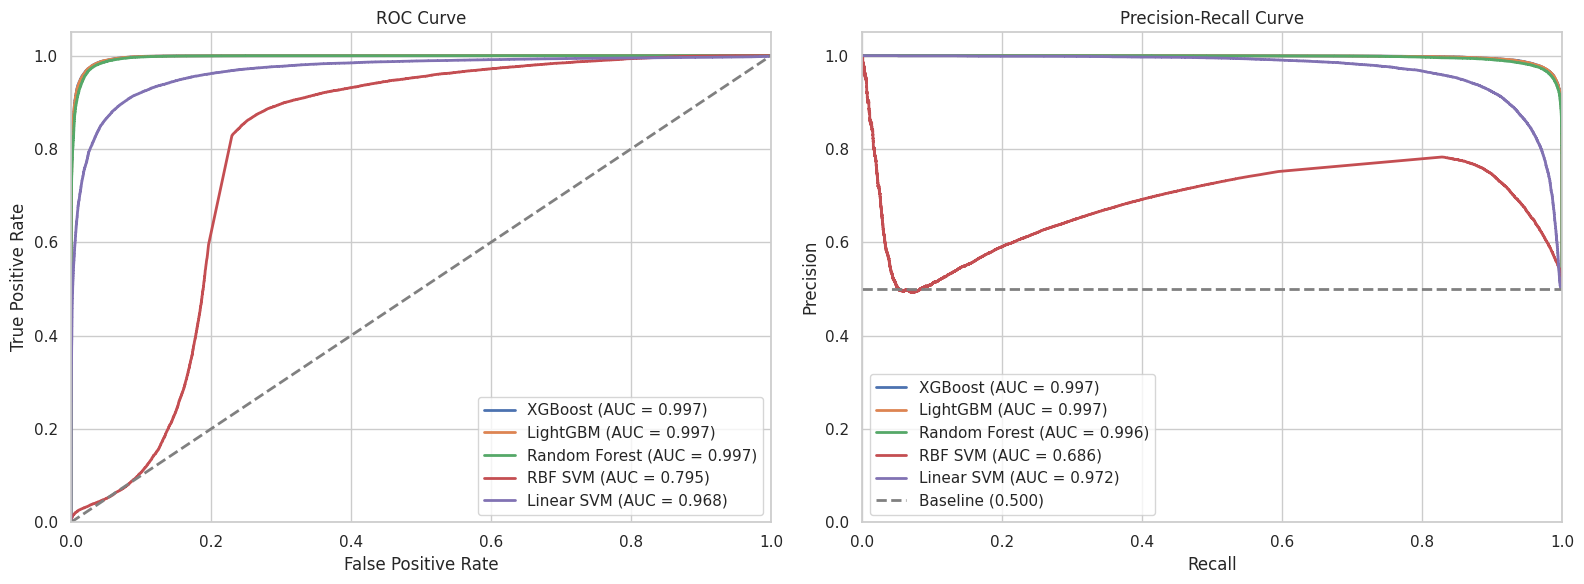

In [5]:
if evaluation_mode != "artifacts" or y_test is None or not probs:
    print("ROC and PR curves require saved model artifacts and predicted probabilities. Skipping in MLflow-only mode.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    plot_roc_curve(probs, y_test, ax=axes[0])
    plot_pr_curve(probs, y_test, ax=axes[1])

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "roc_pr_curves.png", dpi=300)
    plt.show()

### 4.2 Confusion Matrices

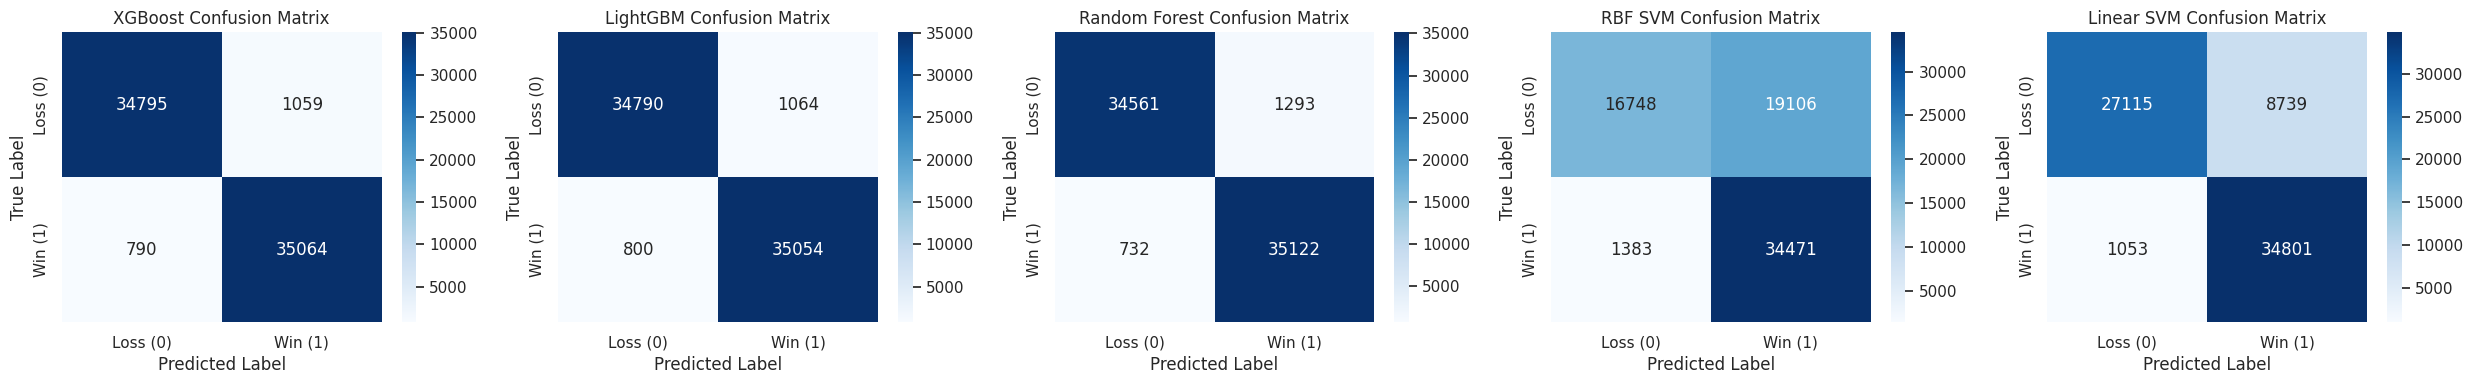

In [6]:
if evaluation_mode != "artifacts" or y_test is None or not preds:
    print("Confusion matrices require saved model artifacts and test predictions. Skipping in MLflow-only mode.")
else:
    fig, axes = plt.subplots(1, len(preds), figsize=(5 * len(preds), 4))

    if len(preds) == 1:
        axes = [axes]

    for i, (name, y_pred) in enumerate(preds.items()):
        plot_confusion_matrix(y_test, y_pred, ax=axes[i], title=f"{name} Confusion Matrix")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "confusion_matrices.png", dpi=300)
    plt.show()

### 4.3 Calibration Curve (Reliability Diagram)

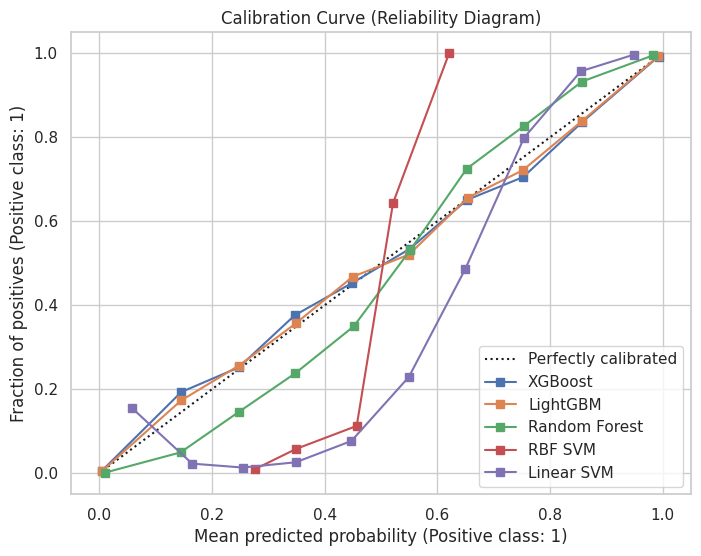

In [7]:
if evaluation_mode != "artifacts" or y_test is None or not probs:
    print("Calibration curves require saved model artifacts and predicted probabilities. Skipping in MLflow-only mode.")
else:
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_calibration_curve(probs, y_test, ax=ax)
    plt.savefig(FIGURES_DIR / "calibration_curve.png", dpi=300)
    plt.show()

### 4.4 Feature Importance (SHAP & Model Native)
This section uses the selected champion model from the comparison table above.
When saved artifacts are unavailable in the current workspace, the interpretability plots are skipped but the champion metrics remain available through MLflow.

/home/amir/dev/lol-match-oracle/src/oracle/evaluation/visualizations.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df, ax=ax, palette='viridis')


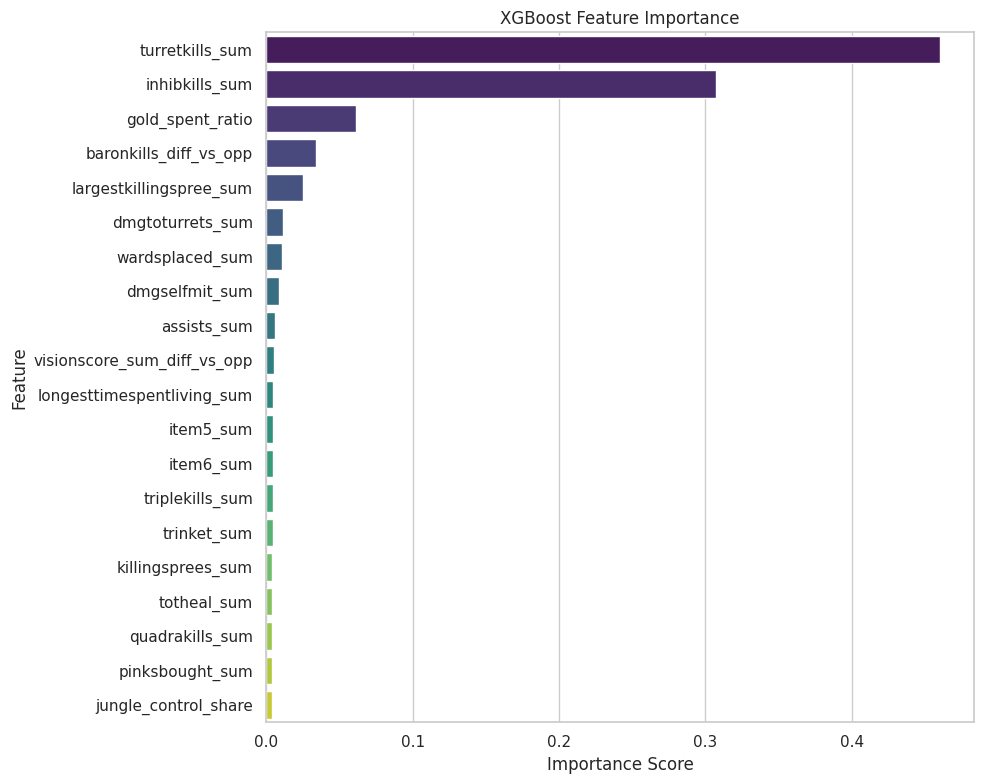

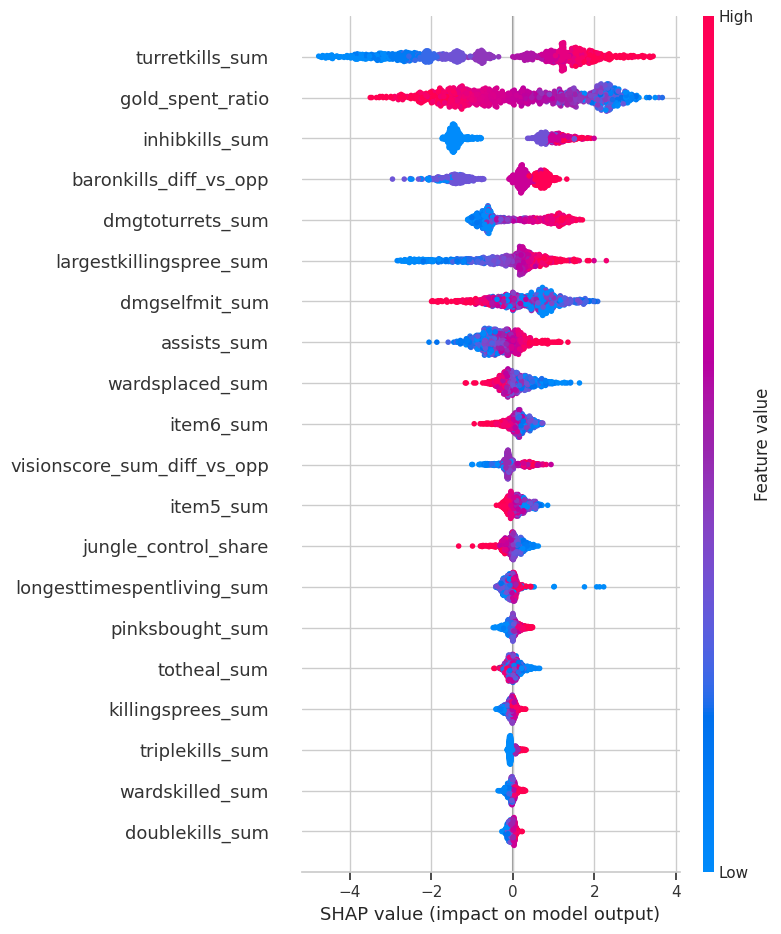

In [8]:
if not artifacts_available_for_analysis:
    print(
        "Feature-importance and SHAP analysis require the saved champion model, "
        "its test matrix, and local artifacts. Skipping in MLflow-only mode."
    )
else:
    champion_model = champion_bundle["model"]
    x_test_champion = champion_bundle["x_test"]

    if hasattr(champion_model, "feature_importances_"):
        importances = champion_model.feature_importances_
        feat_names = x_test_champion.columns
        plot_feature_importance(
            importances,
            feat_names,
            title=f"{champion_name} Feature Importance",
        )
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "feature_importance.png", dpi=300)
        plt.show()

    underlying_model = (
        champion_model._model if hasattr(champion_model, "_model") else champion_model
    )
    x_sample = shap.sample(x_test_champion, min(1000, len(x_test_champion)))
    explainer = shap.TreeExplainer(underlying_model)
    shap_values = explainer.shap_values(x_sample)

    plt.figure(figsize=(10, 8))
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[1], x_sample, show=False)
    else:
        shap.summary_plot(shap_values, x_sample, show=False)

    plt.savefig(FIGURES_DIR / "shap_summary.png", dpi=300, bbox_inches="tight")
    plt.show()

## 5. Statistical Testing
We perform **McNemar's Test** to check if the difference in predictions between models is statistically significant (p < 0.05).

In [9]:
if evaluation_mode != "artifacts" or y_test is None or len(preds) < 2:
    print("McNemar's test requires at least two artifact-backed prediction sets. Skipping in MLflow-only mode.")
else:
    ranked_models = comparison_df["model"].tolist()
    first_model, second_model = ranked_models[:2]

    print(f"McNemar's Test: {first_model} vs {second_model}")
    result_top_pair = mcnemar_test(y_test, preds[first_model], preds[second_model])
    print(
        f"Statistic: {result_top_pair['statistic']:.4f}, "
        f"p-value: {result_top_pair['pvalue']:.4e}"
    )
    if result_top_pair["pvalue"] < 0.05:
        print("=> The top two models are statistically significantly different.")
    else:
        print("=> No statistically significant difference was detected between the top two models.")

McNemar's Test: XGBoost vs LightGBM
Statistic: 0.6782, p-value: 4.1021e-01
=> No statistically significant difference was detected between the top two models.


## 6. Champion Model Selection
The champion model is selected from the comparison table above using ROC-AUC first, then Accuracy, then F1 score.

### Rationale
- Generalization: preference goes to the strongest held-out test result while checking that validation and test performance remain close.
- Bias-Variance: tree ensembles stay competitive here because the post-game feature space is nonlinear and highly collinear.

In [10]:
report_path = export_evaluation_summary(
    metrics_by_model,
    champion_name,
    REPORTS_DIR,
    file_name="evaluation_summary.json",
)
print(f"Evaluation summary written to {report_path}")
display(pd.Series(champion_metrics, name=champion_name))

Evaluation summary written to /home/amir/dev/lol-match-oracle/reports/evaluation/evaluation_summary.json


accuracy       0.974215
precision      0.970683
recall         0.977966
f1             0.974311
roc_auc        0.997262
pr_auc         0.997185
brier_score    0.019108
log_loss       0.065637
Name: XGBoost, dtype: float64

## 7. Dual-Scope Comparison

This appendix compares the latest saved post-game and pre-game training artifacts.

The key interpretation is simple:

- **Post-game** models explain the winner after the match using full match statistics.
- **Pre-game** models predict the winner from draft-side context and historical champion priors only.
- The gap between these scopes is expected and useful: it separates explanation-heavy signals from true draft-time predictive signal.

In [11]:
def _latest_metrics_for_experiment(experiment_dir: Path) -> dict | None:
    metrics_files = sorted(
        experiment_dir.glob("*/*/metrics.json"),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    if not metrics_files:
        return None

    metrics_path = metrics_files[0]
    metadata_path = metrics_path.parent / "model_metadata.json"
    payload = json.loads(metrics_path.read_text(encoding="utf-8"))
    metadata = (
        json.loads(metadata_path.read_text(encoding="utf-8"))
        if metadata_path.exists()
        else {}
    )
    return {
        "scope": metadata.get("scope", "postgame"),
        "model_name": metadata.get("model_name", metrics_path.parent.parent.name),
        "run_name": metadata.get("run_name", metrics_path.parent.name),
        "accuracy": payload.get("test_accuracy"),
        "roc_auc": payload.get("test_roc_auc"),
        "f1": payload.get("test_f1"),
        "metrics_path": str(metrics_path),
    }


scope_comparison_rows = []
for experiment_name in ["02-advanced-models", "03-pregame"]:
    result = _latest_metrics_for_experiment(PROJECT_ROOT / "models" / experiment_name)
    if result is not None:
        scope_comparison_rows.append(result)

scope_comparison_df = pd.DataFrame(scope_comparison_rows)
if scope_comparison_df.empty:
    print("No saved post-game or pre-game metrics were found yet.")
else:
    display(
        scope_comparison_df[["scope", "model_name", "run_name", "accuracy", "roc_auc", "f1"]]
        .sort_values(by=["scope", "roc_auc"], ascending=[True, False])
        .reset_index(drop=True)
    )

,scope,model_name,run_name,accuracy,roc_auc,f1
0,postgame,lightgbm,advanced-lightgbm,0.981843,0.998594,0.981873
